Training set: 1964 days (2018-01-02 00:00:00 to 2023-05-19 00:00:00)
Test set: 655 days (2023-05-20 00:00:00 to 2025-03-04 00:00:00)


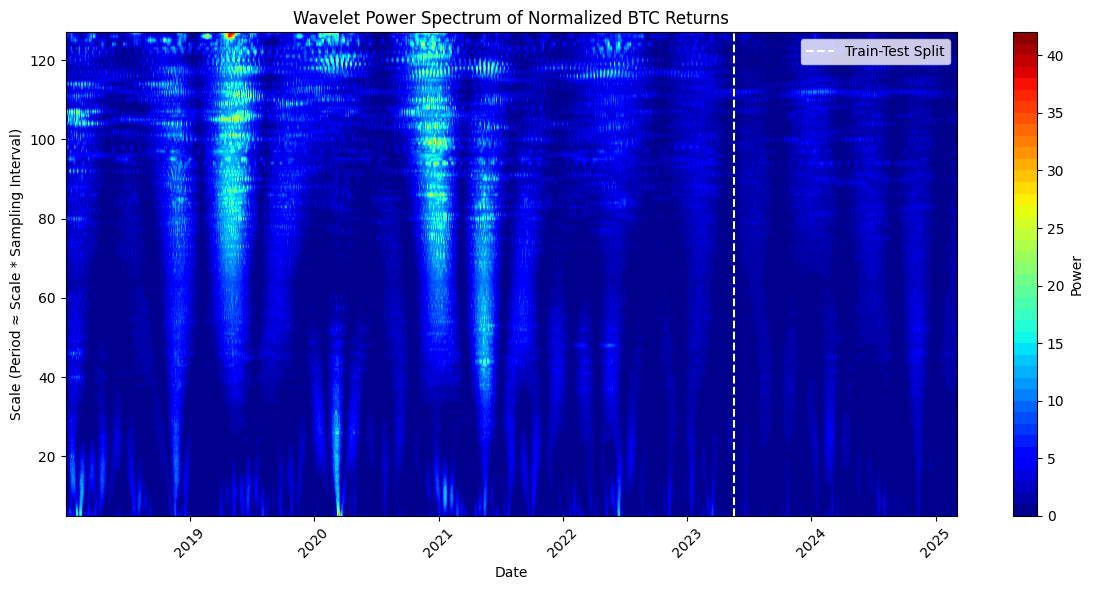

Strategy Performance (Test Set):
  Total Return: 57.93%
  Sharpe Ratio: 0.065329
  Average Daily Return: 0.084983%
  Volatility: 1.300854%
  Maximum Drawdown: 39.344037%
  Skewness: 2.660084


Training Set Regimes:
Regime 0:
  Sharpe Ratio: 0.035412
  Average Return: 5.650084%
  Volatility: 159.553728%
  Max Drawdown: 3123.050864%
  Skewness: -1.048631
  Frequency: 23.94%
Regime 1:
  Sharpe Ratio: -0.022594
  Average Return: -1.076809%
  Volatility: 47.659059%
  Max Drawdown: 996.067259%
  Skewness: 0.046809
  Frequency: 22.73%
Regime 2:
  Sharpe Ratio: -0.033869
  Average Return: -2.981287%
  Volatility: 88.023849%
  Max Drawdown: 3820.437419%
  Skewness: -0.261459
  Frequency: 53.33%

Test Set Regimes:
Regime 0:
  Sharpe Ratio: 0.212132
  Average Return: 25.672015%
  Volatility: 121.019129%
  Max Drawdown: 722.064555%
  Skewness: 0.067428
  Frequency: 7.72%
Regime 1:
  Sharpe Ratio: -0.068826
  Average Return: -3.452151%
  Volatility: 50.157846%
  Max Drawdown: 1135.861024%
  Skewness: -0.545834
  Frequency: 46.14%
Regime 2:
  Sharpe Ratio: 0.074220
  Average Return: 5.817123%
  Volatility: 78.376805%
  Max Drawdown: 732.472708%
  Skewness: 0.212812
  Frequency: 46.14%


In [4]:
import pywt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn import hmm
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import skew

# Set random seed for reproducibility
np.random.seed(42)

# Load BTC OHLCV data from local database
data_path = "/Users/valter.rebelo/MissionControl/data"
btc_file = os.path.join(data_path, "micro/candleData", "bitcoin_candles.csv")

# Load the data
btc = pd.read_csv(btc_file, index_col=0, parse_dates=True)
btc = btc.loc['2018-01-01':'2025-03-06']  # Filter to desired date range
close_prices = btc['close'].values
open_prices = btc['open'].values  # Extract open prices for trading execution

# Data cleaning
close_prices = np.where(close_prices <= 0, np.nanmin(close_prices[close_prices > 0]), close_prices)
close_prices = np.nan_to_num(close_prices, nan=np.nanmean(close_prices))
open_prices = np.where(open_prices <= 0, np.nanmin(open_prices[open_prices > 0]), open_prices)
open_prices = np.nan_to_num(open_prices, nan=np.nanmean(open_prices))

# Compute returns for analysis (based on close prices for signal generation)
returns = np.log(close_prices[1:] / close_prices[:-1])
normalized_returns = (returns - np.mean(returns)) / (np.std(returns) if np.std(returns) > 0 else 1e-10)

# Get dates for x-axis
dates = btc.index[1:]  # Skip first date since we're using returns

# Train-test split (80% train, 20% test)
train_size = int(0.75 * len(normalized_returns))
train_returns = normalized_returns[:train_size]
test_returns = normalized_returns[train_size:]
train_dates = dates[:train_size]
test_dates = dates[train_size:]

print(f"Training set: {len(train_dates)} days ({train_dates[0]} to {train_dates[-1]})")
print(f"Test set: {len(test_dates)} days ({test_dates[0]} to {test_dates[-1]})")

# Compute wavelet features causally using a rolling window
window_size = 60  # Use past 60 days for each wavelet transform
widths = np.arange(5, 128)  # Scales to analyze (periods 5-127 days)
selected_scales = [10, 40, 120]  # Focus on specific periods (≈ 10, 40, 120 days)

# Initialize wavelet feature arrays
train_wavelet_features = []
test_wavelet_features = []

# Helper function to compute wavelet features for a window
def compute_wavelet_features(data_window, widths, selected_scales):
    if len(data_window) < window_size:
        data_window = np.pad(data_window, (window_size - len(data_window), 0), mode='constant', constant_values=0)
    cwtmatr = pywt.cwt(data_window, widths, 'mexh')[0]
    power = np.abs(cwtmatr) ** 2
    # Extract power at selected scales
    features = np.array([power[np.where(widths == scale)[0][0], :] for scale in selected_scales]).T
    return features[-1]  # Return features for the last time step

# Compute wavelet features for training set
for i in range(window_size - 1, len(train_returns)):
    window = train_returns[max(0, i - window_size + 1):i + 1]
    features = compute_wavelet_features(window, widths, selected_scales)
    train_wavelet_features.append(features)

# Compute wavelet features for test set
for i in range(window_size - 1, len(test_returns)):
    test_idx = train_size + i
    window = normalized_returns[max(0, test_idx - window_size + 1):test_idx + 1]
    features = compute_wavelet_features(window, widths, selected_scales)
    test_wavelet_features.append(features)

# Convert to arrays
train_wavelet_features = np.array(train_wavelet_features)
test_wavelet_features = np.array(test_wavelet_features)

# Prepare HMM input: Combine returns and wavelet features
X_train = np.column_stack([train_returns[window_size-1:], train_wavelet_features])
X_test = np.column_stack([test_returns[window_size-1:][:len(test_wavelet_features)], test_wavelet_features])

# Clean any invalid values
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Fit HMM on training data
n_states = 3
model = hmm.GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=100, init_params="mc", random_state=42)
model.startprob_ = np.ones(n_states) / n_states
model.transmat_ = np.ones((n_states, n_states)) / n_states
model.transmat_prior = 1e-2 * np.ones((n_states, n_states))
model.fit(X_train)

# Predict regimes on training and test sets
train_states = model.predict(X_train)
test_states = model.predict(X_test)

# Full wavelet power spectrum for visualization (non-causal, for analysis only)
cwtmatr = pywt.cwt(normalized_returns, widths, 'mexh')[0]
power = np.abs(cwtmatr) ** 2

plt.figure(figsize=(12, 6))
plt.contourf(dates, widths, power, levels=50, cmap='jet')
plt.axvline(x=train_dates[-1], color='white', linestyle='--', label='Train-Test Split')
plt.title('Wavelet Power Spectrum of Normalized BTC Returns')
plt.ylabel('Scale (Period ≈ Scale * Sampling Interval)')
plt.xlabel('Date')
plt.colorbar(label='Power')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot regimes using Plotly with colored markers overlaid on price
train_plot_dates = train_dates[window_size-1:]
test_plot_dates = test_dates[window_size-1:][:len(test_wavelet_features)]
train_plot_prices = close_prices[window_size:train_size+1]
test_plot_prices = close_prices[train_size+window_size-1:][:len(test_wavelet_features)]

# Create Plotly figure
fig = go.Figure()

# Add price traces
fig.add_trace(go.Scatter(
    x=train_plot_dates, y=train_plot_prices, mode='lines', name='BTC Close Price (Train)', line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=test_plot_dates, y=test_plot_prices, mode='lines', name='BTC Close Price (Test)', line=dict(color='green')
))

# Define darker tones for regime markers
regime_colors = {
    0: 'darkred',  # Regime 0 (Strong Bull Market)
    1: 'darkblue',  # Regime 1 (Bear Market with Moderate Decline)
    2: 'darkgreen'  # Regime 2 (Stable Bull Market/Consolidation)
}

# Add regime markers for training set overlaid on price
for state in range(n_states):
    mask = train_states == state
    fig.add_trace(go.Scatter(
        x=train_plot_dates[mask],
        y=train_plot_prices[mask],
        mode='markers',
        name='Regime' if state == 0 else None,  # Only show "Regime" in legend for first trace
        marker=dict(color=regime_colors[state], size=10, symbol='circle', line=dict(color='black', width=1)),
        opacity=0.8,
        showlegend=(state == 0),
        hovertemplate='Date: %{x}<br>Price: %{y:.2f}<br>Regime: %{customdata}<extra></extra>',
        customdata=[f'Regime {state} (Train)'] * sum(mask)
    ))

# Add regime markers for test set overlaid on price
for state in range(n_states):
    mask = test_states == state
    fig.add_trace(go.Scatter(
        x=test_plot_dates[mask],
        y=test_plot_prices[mask],
        mode='markers',
        name='Regime' if state == 0 else None,  # Avoid duplicate legend entries
        marker=dict(color=regime_colors[state], size=6, symbol='circle', line=dict(color='black', width=1)),
        opacity=0.8,
        showlegend=False,
        hovertemplate='Date: %{x}<br>Price: %{y:.2f}<br>Regime: %{customdata}<extra></extra>',
        customdata=[f'Regime {state} (Test)'] * sum(mask)
    ))

# Update layout
fig.update_layout(
    title='BTC Regimes with Wavelet Features (Train-Test Split)',
    xaxis_title='Date',
    yaxis_title='Price',
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)', bordercolor='black', borderwidth=1),
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12),
    margin=dict(l=50, r=50, t=80, b=50)
)
fig.update_xaxes(showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')
fig.update_yaxes(showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')
fig.show()

# Trading Strategy: Buy in Regime 0, Flat in Regime 1, Short in Regime 2
# Signal at close, execute at open
positions = np.zeros(len(test_states))

# Generate positions based on test set regimes (signal at close)
for i in range(len(test_states)):
    if test_states[i] == 0:  # Strong Bull Market
        positions[i] = 1  # Buy
    elif test_states[i] == 1:  # Bear Market with Moderate Decline
        positions[i] = 0  # Flat
    elif test_states[i] == 2:  # Stable Bull Market/Consolidation
        positions[i] = 0  # Short

# Compute open-to-open returns for trading execution
# Align open prices with test set (after window_size adjustment)
open_prices_test = open_prices[train_size+window_size-1:][:len(test_wavelet_features)+1]
open_returns = np.diff(open_prices_test) / open_prices_test[:-1]  # Open[t+1]/Open[t] - 1

# Align positions with open returns (positions[i] applies to open_returns[i])
if len(open_returns) > len(positions):
    open_returns = open_returns[:len(positions)]
elif len(positions) > len(open_returns):
    positions = positions[:len(open_returns)]

# Compute strategy returns: position[t] * open_return[t]
strategy_returns = positions * open_returns

# Verify flat periods (Regime 1 should have 0 return)
for i in range(len(test_states)):
    if test_states[i] == 1:  # Regime 1 (Flat)
        if strategy_returns[i] != 0:
            print(f"Misalignment at index {i}: Regime 1, Position={positions[i]}, Strategy Return={strategy_returns[i]}")
            strategy_returns[i] = 0  # Force flat periods to have 0 return

# Compute cumulative returns
cumulative_returns = np.cumprod(1 + strategy_returns) - 1

# Compute performance metrics
def compute_sharpe(returns, risk_free_rate=0.0):
    return np.mean(returns) / np.std(returns) if np.std(returns) > 0 else 0.0

def compute_max_drawdown(returns):
    cumulative = np.cumprod(1 + returns) - 1
    peak = np.maximum.accumulate(cumulative)
    drawdown = peak - cumulative
    return np.max(drawdown) if len(drawdown) > 0 else 0.0

strategy_sharpe = compute_sharpe(strategy_returns)
strategy_drawdown = compute_max_drawdown(strategy_returns)
strategy_avg_return = np.mean(strategy_returns)
strategy_volatility = np.std(strategy_returns)
strategy_skew = skew(strategy_returns)

print("Strategy Performance (Test Set):")
print(f"  Total Return: {cumulative_returns[-1] * 100:.2f}%")
print(f"  Sharpe Ratio: {strategy_sharpe:.6f}")
print(f"  Average Daily Return: {strategy_avg_return * 100:.6f}%")
print(f"  Volatility: {strategy_volatility * 100:.6f}%")
print(f"  Maximum Drawdown: {strategy_drawdown * 100:.6f}%")
print(f"  Skewness: {strategy_skew:.6f}")

# Plot equity curve
equity_dates = test_plot_dates[1:]  # Align with open returns
if len(equity_dates) > len(cumulative_returns):
    equity_dates = equity_dates[:len(cumulative_returns)]
elif len(cumulative_returns) > len(equity_dates):
    cumulative_returns = cumulative_returns[:len(equity_dates)]

fig_equity = go.Figure()
fig_equity.add_trace(go.Scatter(
    x=equity_dates,
    y=cumulative_returns * 100,
    mode='lines',
    name='Strategy Cumulative Return (%)',
    line=dict(color='purple')
))
fig_equity.update_layout(
    title='Strategy Equity Curve (Test Set)',
    xaxis_title='Date',
    yaxis_title='Cumulative Return (%)',
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12),
    margin=dict(l=50, r=50, t=80, b=50)
)
fig_equity.update_xaxes(showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')
fig_equity.update_yaxes(showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')
fig_equity.show()

# Function to compute metrics for regimes
def compute_sharpe(returns, risk_free_rate=0.0):
    return np.mean(returns) / np.std(returns) if np.std(returns) > 0 else 0.0

def compute_max_drawdown(returns):
    cumulative = np.cumsum(returns)
    peak = np.maximum.accumulate(cumulative)
    drawdown = peak - cumulative
    return np.max(drawdown) if len(drawdown) > 0 else 0.0

# Analyze regimes for training set with additional metrics
print("Training Set Regimes:")
for i in range(n_states):
    state_returns = train_returns[window_size-1:][train_states == i]
    sharpe = compute_sharpe(state_returns)
    avg_return = np.mean(state_returns)
    volatility = np.std(state_returns)
    max_drawdown = compute_max_drawdown(state_returns)
    return_skew = skew(state_returns) if len(state_returns) > 1 else 0.0
    print(f"Regime {i}:")
    print(f"  Sharpe Ratio: {sharpe:.6f}")
    print(f"  Average Return: {avg_return * 100:.6f}%")
    print(f"  Volatility: {volatility * 100:.6f}%")
    print(f"  Max Drawdown: {max_drawdown * 100:.6f}%")
    print(f"  Skewness: {return_skew:.6f}")
    print(f"  Frequency: {len(state_returns) / len(train_returns[window_size-1:]):.2%}")

# Analyze regimes for test set with additional metrics
print("\nTest Set Regimes:")
for i in range(n_states):
    state_returns = test_returns[window_size-1:][:len(test_wavelet_features)][test_states == i]
    sharpe = compute_sharpe(state_returns)
    avg_return = np.mean(state_returns)
    volatility = np.std(state_returns)
    max_drawdown = compute_max_drawdown(state_returns)
    return_skew = skew(state_returns) if len(state_returns) > 1 else 0.0
    print(f"Regime {i}:")
    print(f"  Sharpe Ratio: {sharpe:.6f}")
    print(f"  Average Return: {avg_return * 100:.6f}%")
    print(f"  Volatility: {volatility * 100:.6f}%")
    print(f"  Max Drawdown: {max_drawdown * 100:.6f}%")
    print(f"  Skewness: {return_skew:.6f}")
    print(f"  Frequency: {len(state_returns) / len(test_returns[window_size-1:][:len(test_wavelet_features)]):.2%}")

Training set: 2786 days (2015-01-02 00:00:00 to 2022-08-18 00:00:00)
Test set: 929 days (2022-08-19 00:00:00 to 2025-03-04 00:00:00)


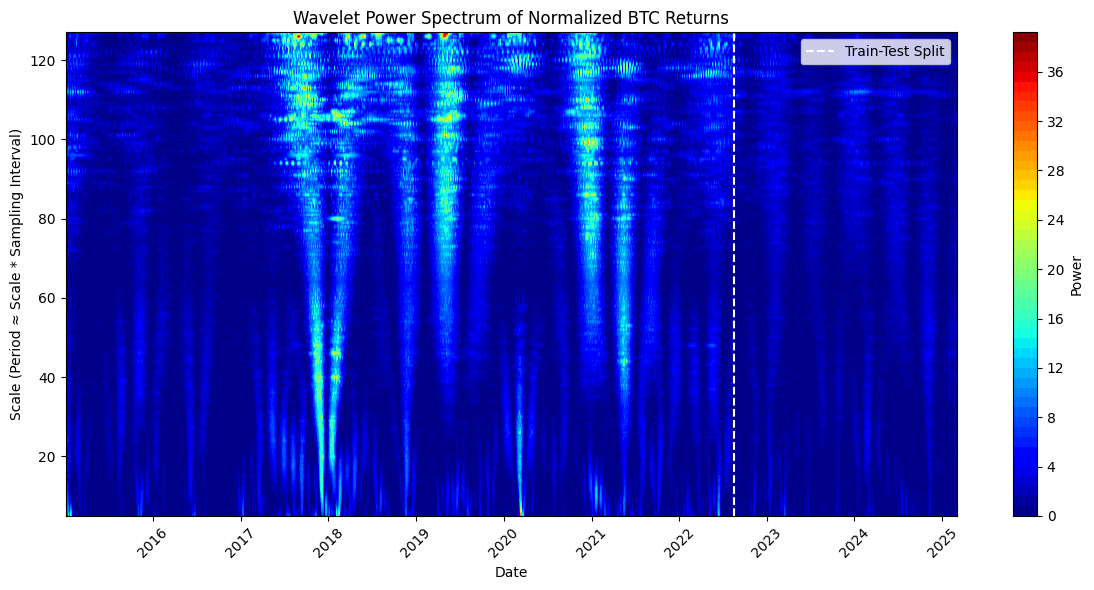

Strategy Performance (Test Set):
  Total Return: 233.04%
  Sharpe Ratio: 0.096295
  Average Daily Return: 0.153294%
  Volatility: 1.591920%
  Maximum Drawdown: 48.81%
  Skewness: 1.618635

Buy & Hold Performance (Test Set):
  Total Return: 351.72%
  Sharpe Ratio: 0.081171
  Average Daily Return: 0.209678%
  Volatility: 2.583185%
  Maximum Drawdown: 105.95%
  Skewness: 0.349582


Training Set Regimes (2 States):
Regime 0:
  Sharpe Ratio: 0.025480
  Average Return: 0.142501%
  Volatility: 5.592678%
  Max Drawdown: 196.130895%
  Skewness: -0.529267
  Frequency: 35.95%
Regime 1:
  Sharpe Ratio: 0.073341
  Average Return: 0.173630%
  Volatility: 2.367423%
  Max Drawdown: 45.558670%
  Skewness: -0.082910
  Frequency: 64.05%

Test Set Regimes (2 States):
Regime 0:
  Sharpe Ratio: 0.189569
  Average Return: 0.921902%
  Volatility: 4.863140%
  Max Drawdown: 20.929169%
  Skewness: -0.396902
  Frequency: 10.53%
Regime 1:
  Sharpe Ratio: 0.036386
  Average Return: 0.078383%
  Volatility: 2.154217%
  Max Drawdown: 32.431827%
  Skewness: 0.164805
  Frequency: 89.47%


In [23]:
import pywt
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn import hmm
import os
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import skew

# Set random seed for reproducibility
np.random.seed(42)

# Load BTC OHLCV data from local database
data_path = "/Users/valter.rebelo/MissionControl/data"
btc_file = os.path.join(data_path, "micro/candleData", "bitcoin_candles.csv")

# Load the data
btc = pd.read_csv(btc_file, index_col=0, parse_dates=True)
btc = btc.loc['2015-01-01':'2025-03-06']  # Filter to desired date range
close_prices = btc['close'].values
open_prices = btc['open'].values  # Extract open prices for trading execution

# Data cleaning
close_prices = np.where(close_prices <= 0, np.nanmin(close_prices[close_prices > 0]), close_prices)
close_prices = np.nan_to_num(close_prices, nan=np.nanmean(close_prices))
open_prices = np.where(open_prices <= 0, np.nanmin(open_prices[open_prices > 0]), open_prices)
open_prices = np.nan_to_num(open_prices, nan=np.nanmean(open_prices))

# Compute returns for analysis (based on close prices for signal generation)
returns = np.log(close_prices[1:] / close_prices[:-1])
normalized_returns = (returns - np.mean(returns)) / (np.std(returns) if np.std(returns) > 0 else 1e-10)

# Get dates for x-axis
dates = btc.index[1:]  # Skip first date since we're using returns

# Train-test split (75% train, 25% test)
train_size = int(0.75 * len(normalized_returns))
train_returns = normalized_returns[:train_size]
test_returns = normalized_returns[train_size:]
train_dates = dates[:train_size]
test_dates = dates[train_size:]
train_returns_orig = returns[:train_size]
test_returns_orig = returns[train_size:]  # Use original returns for metrics

print(f"Training set: {len(train_dates)} days ({train_dates[0]} to {train_dates[-1]})")
print(f"Test set: {len(test_dates)} days ({test_dates[0]} to {test_dates[-1]})")

# Compute wavelet features causally using a rolling window
window_size = 75  # Use past 60 days for each wavelet transform
widths = np.arange(5, 128)  # Scales to analyze (periods 5-127 days)
selected_scales = [10, 40, 120]  # Focus on specific periods (≈ 10, 40, 120 days)

# Initialize wavelet feature arrays
train_wavelet_features = []
test_wavelet_features = []

# Helper function to compute wavelet features for a window
def compute_wavelet_features(data_window, widths, selected_scales):
    if len(data_window) < window_size:
        data_window = np.pad(data_window, (window_size - len(data_window), 0), mode='constant', constant_values=0)
    cwtmatr = pywt.cwt(data_window, widths, 'mexh')[0]
    power = np.abs(cwtmatr) ** 2
    features = np.array([power[np.where(widths == scale)[0][0], :] for scale in selected_scales]).T
    return features[-1]  # Return features for the last time step

# Compute wavelet features for training set
for i in range(window_size - 1, len(train_returns)):
    window = train_returns[max(0, i - window_size + 1):i + 1]
    features = compute_wavelet_features(window, widths, selected_scales)
    train_wavelet_features.append(features)

# Compute wavelet features for test set
for i in range(window_size - 1, len(test_returns)):
    test_idx = train_size + i
    window = normalized_returns[max(0, test_idx - window_size + 1):test_idx + 1]
    features = compute_wavelet_features(window, widths, selected_scales)
    test_wavelet_features.append(features)

# Convert to arrays
train_wavelet_features = np.array(train_wavelet_features)
test_wavelet_features = np.array(test_wavelet_features)

# Prepare HMM input: Combine returns and wavelet features
X_train = np.column_stack([train_returns[window_size-1:], train_wavelet_features])
X_test = np.column_stack([test_returns[window_size-1:][:len(test_wavelet_features)], test_wavelet_features])

# Clean any invalid values
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Fit HMM on training data with 2 states
n_states = 2
model = hmm.GaussianHMM(n_components=n_states, covariance_type="diag", n_iter=100, init_params="mc", random_state=42)
model.startprob_ = np.ones(n_states) / n_states
model.transmat_ = np.ones((n_states, n_states)) / n_states
model.transmat_prior = 1e-2 * np.ones((n_states, n_states))
model.fit(X_train)

# Predict regimes on training and test sets
train_states = model.predict(X_train)
test_states = model.predict(X_test)

# Full wavelet power spectrum for visualization (non-causal, for analysis only)
cwtmatr = pywt.cwt(normalized_returns, widths, 'mexh')[0]
power = np.abs(cwtmatr) ** 2

plt.figure(figsize=(12, 6))
plt.contourf(dates, widths, power, levels=50, cmap='jet')
plt.axvline(x=train_dates[-1], color='white', linestyle='--', label='Train-Test Split')
plt.title('Wavelet Power Spectrum of Normalized BTC Returns')
plt.ylabel('Scale (Period ≈ Scale * Sampling Interval)')
plt.xlabel('Date')
plt.colorbar(label='Power')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot regimes using Plotly with colored markers overlaid on price
train_plot_dates = train_dates[window_size-1:]
test_plot_dates = test_dates[window_size-1:][:len(test_wavelet_features)]
train_plot_prices = close_prices[window_size:train_size+1]
test_plot_prices = close_prices[train_size+window_size-1:][:len(test_wavelet_features)]

# Create Plotly figure
fig = go.Figure()

# Add price traces
fig.add_trace(go.Scatter(
    x=train_plot_dates, y=train_plot_prices, mode='lines', name='BTC Close Price (Train)', line=dict(color='blue')
))
fig.add_trace(go.Scatter(
    x=test_plot_dates, y=test_plot_prices, mode='lines', name='BTC Close Price (Test)', line=dict(color='green')
))

# Define darker tones for regime markers
regime_colors = {
    0: 'darkred',  # State 0 (e.g., Bull Market)
    1: 'darkblue'  # State 1 (e.g., Bear Market)
}

# Add regime markers for training set overlaid on price
for state in range(n_states):
    mask = train_states == state
    fig.add_trace(go.Scatter(
        x=train_plot_dates[mask],
        y=train_plot_prices[mask],
        mode='markers',
        name='Regime' if state == 0 else None,  # Only show "Regime" in legend for first trace
        marker=dict(color=regime_colors[state], size=10, symbol='circle', line=dict(color='black', width=1)),
        opacity=0.8,
        showlegend=(state == 0),
        hovertemplate='Date: %{x}<br>Price: %{y:.2f}<br>Regime: %{customdata}<extra></extra>',
        customdata=[f'Regime {state} (Train)'] * sum(mask)
    ))

# Add regime markers for test set overlaid on price
for state in range(n_states):
    mask = test_states == state
    fig.add_trace(go.Scatter(
        x=test_plot_dates[mask],
        y=test_plot_prices[mask],
        mode='markers',
        name='Regime' if state == 0 else None,  # Avoid duplicate legend entries
        marker=dict(color=regime_colors[state], size=10, symbol='circle', line=dict(color='black', width=1)),
        opacity=0.8,
        showlegend=False,
        hovertemplate='Date: %{x}<br>Price: %{y:.2f}<br>Regime: %{customdata}<extra></extra>',
        customdata=[f'Regime {state} (Test)'] * sum(mask)
    ))

# Update layout
fig.update_layout(
    title='BTC Regimes with Wavelet Features (Train-Test Split) - 2 States',
    xaxis_title='Date',
    yaxis_title='Price',
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)', bordercolor='black', borderwidth=1),
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12),
    margin=dict(l=50, r=50, t=80, b=50)
)
fig.update_xaxes(showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')
fig.update_yaxes(showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')
fig.show()

# Trading Strategy: Buy in State 0, Flat in State 1
# Signal at close, execute at open
positions = np.zeros(len(test_states))

# Generate positions based on test set regimes (signal at close)
for i in range(len(test_states)):
    if test_states[i] == 0:  # Bull Market
        positions[i] = 1  # Buy
    else:  # State 1 (Bear Market)
        positions[i] = 0  # Flat

# Compute open-to-open returns for trading execution
open_prices_test = open_prices[train_size+window_size-1:][:len(test_wavelet_features)+1]
open_returns = np.diff(open_prices_test) / open_prices_test[:-1]  # Open[t+1]/Open[t] - 1

# Align positions with open returns
if len(open_returns) > len(positions):
    open_returns = open_returns[:len(positions)]
elif len(positions) > len(open_returns):
    positions = positions[:len(open_returns)]

# Compute strategy returns: position[t] * open_return[t]
strategy_returns = positions * open_returns

# Verify flat periods (State 1 should have 0 return)
for i in range(len(test_states)):
    if test_states[i] == 1:  # Flat
        if strategy_returns[i] != 0:
            print(f"Misalignment at index {i}: State 1, Position={positions[i]}, Strategy Return={strategy_returns[i]}")
            strategy_returns[i] = 0  # Force flat periods to have 0 return

# Compute cumulative returns for strategy
cumulative_returns = np.cumprod(1 + strategy_returns) - 1

# Compute buy and hold returns for the same period
buy_hold_returns = open_returns  # Buy and hold would experience all returns
buy_hold_cumulative = np.cumprod(1 + buy_hold_returns) - 1

# Compute performance metrics
def compute_sharpe(returns, risk_free_rate=0.0):
    return np.mean(returns) / np.std(returns) if np.std(returns) > 0 else 0.0

def compute_max_drawdown(returns):
    cumulative = np.cumprod(1 + returns) - 1
    peak = np.maximum.accumulate(cumulative)
    drawdown = peak - cumulative
    return np.max(drawdown) if len(drawdown) > 0 else 0.0

strategy_sharpe = compute_sharpe(strategy_returns)
strategy_drawdown = compute_max_drawdown(strategy_returns)
strategy_avg_return = np.mean(strategy_returns)
strategy_volatility = np.std(strategy_returns)
strategy_skew = skew(strategy_returns)

buy_hold_sharpe = compute_sharpe(buy_hold_returns)
buy_hold_drawdown = compute_max_drawdown(buy_hold_returns)
buy_hold_avg_return = np.mean(buy_hold_returns)
buy_hold_volatility = np.std(buy_hold_returns)
buy_hold_skew = skew(buy_hold_returns)

print("Strategy Performance (Test Set):")
print(f"  Total Return: {cumulative_returns[-1] * 100:.2f}%")
print(f"  Sharpe Ratio: {strategy_sharpe:.6f}")
print(f"  Average Daily Return: {strategy_avg_return * 100:.6f}%")
print(f"  Volatility: {strategy_volatility * 100:.6f}%")
print(f"  Maximum Drawdown: {strategy_drawdown * 100:.2f}%")
print(f"  Skewness: {strategy_skew:.6f}")

print("\nBuy & Hold Performance (Test Set):")
print(f"  Total Return: {buy_hold_cumulative[-1] * 100:.2f}%")
print(f"  Sharpe Ratio: {buy_hold_sharpe:.6f}")
print(f"  Average Daily Return: {buy_hold_avg_return * 100:.6f}%")
print(f"  Volatility: {buy_hold_volatility * 100:.6f}%")
print(f"  Maximum Drawdown: {buy_hold_drawdown * 100:.2f}%")
print(f"  Skewness: {buy_hold_skew:.6f}")

# Plot equity curve with both strategy and buy & hold
equity_dates = test_plot_dates[1:]  # Align with open returns
if len(equity_dates) > len(cumulative_returns):
    equity_dates = equity_dates[:len(cumulative_returns)]
elif len(cumulative_returns) > len(equity_dates):
    cumulative_returns = cumulative_returns[:len(equity_dates)]
    
# Ensure buy_hold_cumulative has the same length
buy_hold_cumulative = buy_hold_cumulative[:len(equity_dates)]

fig_equity = go.Figure()
fig_equity.add_trace(go.Scatter(
    x=equity_dates,
    y=cumulative_returns * 100,
    mode='lines',
    name='Strategy Cumulative Return (%)',
    line=dict(color='purple')
))
fig_equity.add_trace(go.Scatter(
    x=equity_dates,
    y=buy_hold_cumulative * 100,
    mode='lines',
    name='Buy & Hold Cumulative Return (%)',
    line=dict(color='orange')
))
fig_equity.update_layout(
    title='Strategy vs Buy & Hold Equity Curve (Test Set) - 2 States',
    xaxis_title='Date',
    yaxis_title='Cumulative Return (%)',
    hovermode='x unified',
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(size=12),
    margin=dict(l=50, r=50, t=80, b=50),
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.8)', bordercolor='black', borderwidth=1)
)
fig_equity.update_xaxes(showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')
fig_equity.update_yaxes(showline=True, linewidth=1, linecolor='black', gridcolor='lightgrey')
fig_equity.show()

# Function to compute metrics for regimes
def compute_sharpe(returns, risk_free_rate=0.0):
    return np.mean(returns) / np.std(returns) if np.std(returns) > 0 else 0.0

def compute_max_drawdown(returns):
    cumulative = np.cumsum(returns)
    peak = np.maximum.accumulate(cumulative)
    drawdown = peak - cumulative
    return np.max(drawdown) if len(drawdown) > 0 else 0.0

# Analyze regimes for training set with original returns
train_returns_orig_adjusted = returns[window_size-1:train_size]
print("Training Set Regimes (2 States):")
for i in range(n_states):
    state_returns = train_returns_orig_adjusted[train_states == i]
    sharpe = compute_sharpe(state_returns)
    avg_return = np.mean(state_returns)
    volatility = np.std(state_returns)
    max_drawdown = compute_max_drawdown(state_returns)
    return_skew = skew(state_returns) if len(state_returns) > 1 else 0.0
    print(f"Regime {i}:")
    print(f"  Sharpe Ratio: {sharpe:.6f}")
    print(f"  Average Return: {avg_return * 100:.6f}%")
    print(f"  Volatility: {volatility * 100:.6f}%")
    print(f"  Max Drawdown: {max_drawdown * 100:.6f}%")
    print(f"  Skewness: {return_skew:.6f}")
    print(f"  Frequency: {len(state_returns) / len(train_returns_orig_adjusted):.2%}")

# Analyze regimes for test set with original returns
test_returns_orig_adjusted = returns[train_size+window_size-1:train_size+window_size-1+len(test_wavelet_features)]
print("\nTest Set Regimes (2 States):")
for i in range(n_states):
    state_returns = test_returns_orig_adjusted[test_states == i]
    sharpe = compute_sharpe(state_returns)
    avg_return = np.mean(state_returns)
    volatility = np.std(state_returns)
    max_drawdown = compute_max_drawdown(state_returns)
    return_skew = skew(state_returns) if len(state_returns) > 1 else 0.0
    print(f"Regime {i}:")
    print(f"  Sharpe Ratio: {sharpe:.6f}")
    print(f"  Average Return: {avg_return * 100:.6f}%")
    print(f"  Volatility: {volatility * 100:.6f}%")
    print(f"  Max Drawdown: {max_drawdown * 100:.6f}%")
    print(f"  Skewness: {return_skew:.6f}")
    print(f"  Frequency: {len(state_returns) / len(test_returns_orig_adjusted):.2%}")